# QR Code Generator

Generate styled QR codes with logo and text.

In [18]:
import os
from io import BytesIO
import qrcode
from qrcode.image.styledpil import StyledPilImage
from qrcode.image.styles.moduledrawers import RoundedModuleDrawer
from PIL import Image, ImageDraw, ImageFont
import cairosvg

In [21]:
def generate_qr_with_logo(data: str, output_filename: str = "qr_code", logo_path: str = None, text_below: str = None):
    """
    Generate a black styled QR code with optional logo and text.
    Saves as PNG.
    
    Args:
        data: URL or text to encode
        output_filename: Output filename without extension
        logo_path: Path to logo (PNG, JPG, or SVG)
        text_below: Text to display below QR code
    """
    # Create QR code
    qr = qrcode.QRCode(
        version=1,
        error_correction=qrcode.constants.ERROR_CORRECT_H,
        box_size=10,
        border=4,
    )
    qr.add_data(data)
    qr.make(fit=True)
    
    # Generate styled QR code
    qr_img = qr.make_image(
        image_factory=StyledPilImage,
        module_drawer=RoundedModuleDrawer(),
        fill_color="black",
        back_color="white"
    )
    
    if not isinstance(qr_img, Image.Image):
        qr_img = qr_img.convert('RGB')
    
    # Add logo
    if logo_path and os.path.exists(logo_path):
        if logo_path.lower().endswith('.svg'):
            png_data = cairosvg.svg2png(url=logo_path, output_width=200, output_height=200)
            logo = Image.open(BytesIO(png_data))
        else:
            logo = Image.open(logo_path)
        
        # Resize logo
        qr_width, qr_height = qr_img.size
        logo_size = qr_width // 5
        logo.thumbnail((logo_size, logo_size), Image.Resampling.LANCZOS)
        
        # Add white background to logo
        padding = 10
        logo_bg = Image.new('RGB', (logo.size[0] + padding*2, logo.size[1] + padding*2), 'white')
        if logo.mode == 'RGBA':
            logo_bg.paste(logo, (padding, padding), logo)
        else:
            logo_bg.paste(logo, (padding, padding))
        
        # Center logo on QR code
        logo_pos = ((qr_width - logo_bg.size[0]) // 2, (qr_height - logo_bg.size[1]) // 2)
        qr_img.paste(logo_bg, logo_pos)
    
    # Add text below
    if text_below:
        # Load font first to calculate text size
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 18)
        except:
            font = ImageFont.load_default()
        
        # Create temporary draw to measure text
        temp_draw = ImageDraw.Draw(Image.new('RGB', (1, 1)))
        
        # Split text into lines and measure
        lines = text_below.split('\n')
        line_heights = []
        max_width = 0
        
        for line in lines:
            bbox = temp_draw.textbbox((0, 0), line, font=font)
            line_width = bbox[2] - bbox[0]
            line_height = bbox[3] - bbox[1]
            max_width = max(max_width, line_width)
            line_heights.append(line_height)
        
        # Calculate total text height with spacing
        line_spacing = 5
        total_text_height = sum(line_heights) + line_spacing * (len(lines) - 1)
        text_area_height = total_text_height + 20
        
        # Create final image with space for text
        final_img = Image.new('RGB', (qr_img.size[0], qr_img.size[1] + text_area_height), 'white')
        final_img.paste(qr_img, (0, 0))
        
        # Draw each line centered
        draw = ImageDraw.Draw(final_img)
        current_y = qr_img.size[1] - 20
        
        for i, line in enumerate(lines):
            bbox = draw.textbbox((0, 0), line, font=font)
            line_width = bbox[2] - bbox[0]
            text_x = (final_img.size[0] - line_width) // 2
            
            draw.text((text_x, current_y), line, fill='black', font=font)
            current_y += line_heights[i] + line_spacing
        
        qr_img = final_img
    
    # Save PNG
    png_file = f"{output_filename}.png"
    qr_img.save(png_file, dpi=(300, 300))
    print(f"✓ Saved: {png_file}")
    
    return qr_img

✓ Saved: qr_kangoo.png


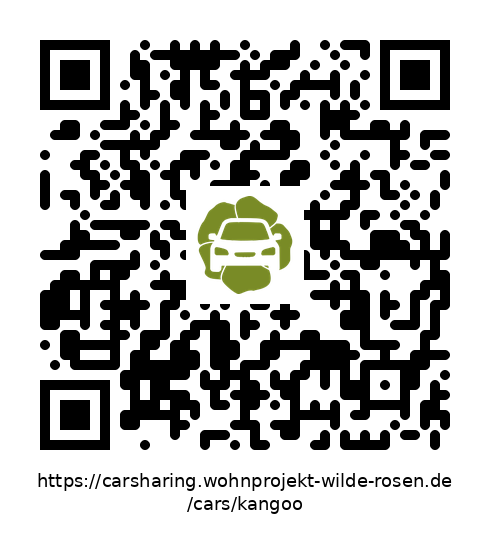

In [ ]:
# Generate QR code with logo and text
logo_path = "../../public/carsharing_logo.svg"

cars = ["zoe", "jogger", "kona", ""]

generate_qr_with_logo(
    data="https://carsharing.wohnprojekt-wilde-rosen.de/cars/kangoo",
    output_filename="qr_kangoo",
    logo_path=logo_path,
    text_below="https://carsharing.wohnprojekt-wilde-rosen.de\n/cars/kangoo"
)